# Outputs for 6th Mag LGS

## Setup Materials

In [6]:
import pylab as plt
import numpy as np
from paarti.utils import maos_utils
from paarti import psfs, psf_plots

# psf_x = [0, 5, 10, 15, 20, 25, 30, 35]  # arcsec
# psf_y = [0, 0,  0,  0,  0,  0,  0,  0,  0,  0]  # arcsec
# psf_wvl = [432, 544, 652, 810, 877, 1020, 1248, 1673, 2200]

night = "2026mar04"
set_num = 19
image_num = 2

# Write a function to get night_in_nums from night or vice versa
def get_night_in_nums(night):
    month_str_to_num = {
        "jan": "01",
        "feb": "02",
        "mar": "03",
        "apr": "04",
        "may": "05",
        "jun": "06",
        "jul": "07",
        "aug": "08",
        "sep": "09",
        "oct": "10",
        "nov": "11",
        "dec": "12"
    }
    year = night[:4]
    month_str = night[4:7].lower()
    day = night[7:9]
    
    month_num = month_str_to_num.get(month_str)
    if month_num is None:
        raise ValueError(f"Invalid month string: {month_str}")
    
    return f"{year[2:4]}{month_num}{day}"

night_in_nums = get_night_in_nums(night)
directory = f'/g/lu/data/kapa/{night}/maos/i{night_in_nums}_a{set_num:03d}{image_num:03d}.fits/A_keck_kapa_compare_sky_4lgs_template_seed1/'
seed = 1
print(directory)
%matplotlib inline

/g/lu/data/kapa/2026mar04/maos/i260304_a019002.fits/A_keck_kapa_compare_sky_4lgs_template_seed1/


# Strehl vs. Radius

In [7]:
mets = maos_utils.get_psf_metrics_over_field(directory, seed=seed)
x, y, w, strehl, fwhm_g, fwhm_e, r_ee50, r_ee80 = mets

Looking in /g/lu/data/kapa/2026mar04/maos/i260304_a019002.fits/A_keck_kapa_compare_sky_4lgs_template_seed1/ for simulation results...
xx =  0 yy =  2
xx =  -6 yy =  0
xx =  -8 yy =  0
xx =  0 yy =  12
xx =  2 yy =  0
xx =  -10 yy =  0
xx =  0 yy =  4
xx =  0 yy =  10
xx =  0 yy =  6
xx =  6 yy =  0
xx =  0 yy =  0
xx =  4 yy =  0
xx =  12 yy =  0
xx =  8 yy =  0
xx =  10 yy =  0
xx =  -2 yy =  0
xx =  0 yy =  8
xx =  -4 yy =  0
xx =  -12 yy =  0


In [8]:
x.shape

(19, 4)

In [9]:
y.shape

(19, 4)

In [10]:
r = np.sqrt(x**2 + y**2)
r.shape

(19, 4)

In [11]:
r

array([[ 2.,  2.,  2.,  2.],
       [ 6.,  6.,  6.,  6.],
       [ 8.,  8.,  8.,  8.],
       [12., 12., 12., 12.],
       [ 2.,  2.,  2.,  2.],
       [10., 10., 10., 10.],
       [ 4.,  4.,  4.,  4.],
       [10., 10., 10., 10.],
       [ 6.,  6.,  6.,  6.],
       [ 6.,  6.,  6.,  6.],
       [ 0.,  0.,  0.,  0.],
       [ 4.,  4.,  4.,  4.],
       [12., 12., 12., 12.],
       [ 8.,  8.,  8.,  8.],
       [10., 10., 10., 10.],
       [ 2.,  2.,  2.,  2.],
       [ 8.,  8.,  8.,  8.],
       [ 4.,  4.,  4.,  4.],
       [12., 12., 12., 12.]])

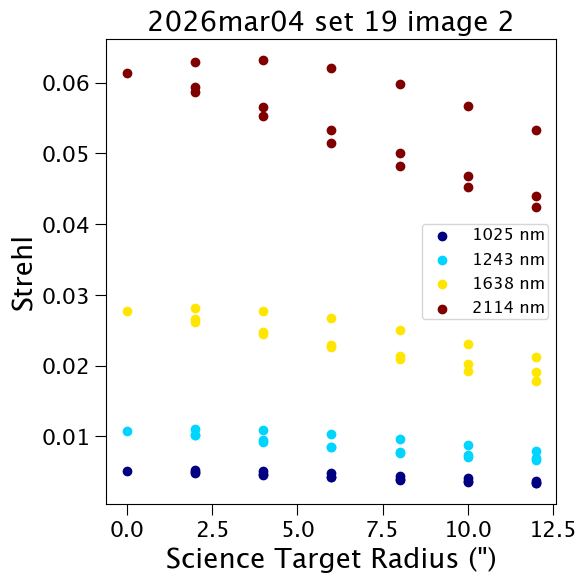

In [12]:
n_wvl = r.shape[1]
colors = plt.cm.jet(np.linspace(0,1,n_wvl))

plt.figure(1)

for ww in range(n_wvl):
    label = f'{w[0, ww]*1e3:3.0f} nm'
    plt.scatter(r[:, ww], strehl[:, ww], color=colors[ww], label=label)    

plt.xlabel('Science Target Radius (")')
plt.ylabel('Strehl')
# plt.axvline(10, linestyle='--', color='grey', label="KLGS constellation radius")
# plt.text(31, 0.2, 'LGS radius', color='grey')
plt.title('2026mar04 set 19 image 2')
plt.legend(fontsize=12)
plt.show()

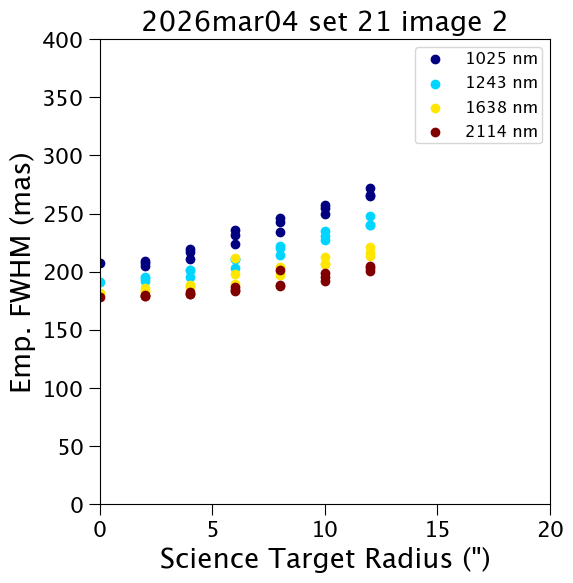

In [13]:
n_wvl = r.shape[1]
colors = plt.cm.jet(np.linspace(0,1,n_wvl))

plt.figure(1)

for ww in range(n_wvl):
    label = f'{w[0, ww]*1e3:3.0f} nm'
    plt.scatter(r[:, ww], fwhm_e[:, ww], color=colors[ww], label=label)    

plt.legend(fontsize=12)
plt.xlabel('Science Target Radius (")')
plt.ylabel('Emp. FWHM (mas)')
# plt.axvline(30, linestyle='--', color='grey')
plt.xlim(0, 20)
plt.ylim(0, 400)
# plt.text(31, 0.2, 'LGS radius', color='grey')
plt.title('2026mar04 set 21 image 2')

plt.show()

In [14]:
r_ee80.shape

(19, 4)

(0.0, 400.0)

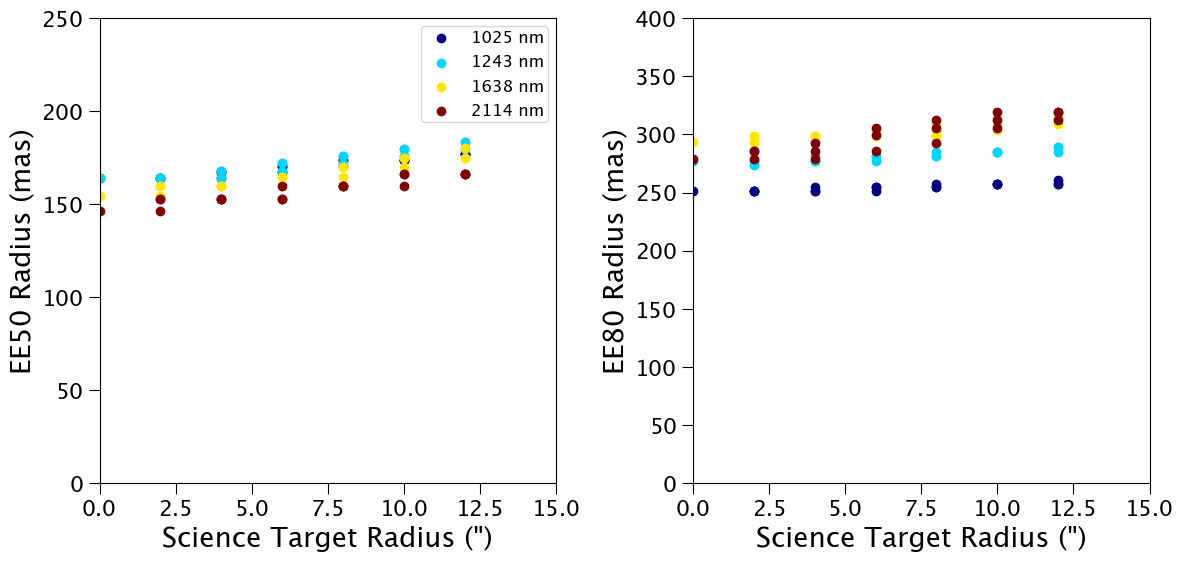

In [15]:
n_wvl = r.shape[1]
colors = plt.cm.jet(np.linspace(0,1,n_wvl))

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(wspace=0.3)
    
for ww in range(n_wvl):
    label = f'{w[0, ww]*1e3:3.0f} nm'
    axs[0].scatter(r[:, ww], r_ee50[:, ww], color=colors[ww], label=label)    
    axs[1].scatter(r[:, ww], r_ee80[:, ww], color=colors[ww])    

axs[0].legend(fontsize=12)
axs[0].set_xlabel('Science Target Radius (")')
axs[1].set_xlabel('Science Target Radius (")')
axs[0].set_ylabel('EE50 Radius (mas)')
axs[1].set_ylabel('EE80 Radius (mas)')
# axs[0].axvline(30, linestyle='--', color='grey')
# axs[1].axvline(30, linestyle='--', color='grey')
axs[0].set_xlim(0, 15)
axs[0].set_ylim(0, 250)
axs[1].set_xlim(0, 15)
axs[1].set_ylim(0, 400)
# axs[1].text(29, 20, 'LGS radius', color='grey', ha='right')

## Display PSFs.

800 nm PSFs vs. distance. 

In [16]:
# Pulled straight from maos_done.conf
nwfs = maos_utils.get_parameter_from_done_conf(directory, "powfs.nwfs")
wfs_x = maos_utils.get_parameter_from_done_conf(directory, "wfs.thetax")
wfs_y = maos_utils.get_parameter_from_done_conf(directory, "wfs.thetay")
wvl = maos_utils.get_parameter_from_done_conf(directory, "evl.wvl")

print(nwfs)
lgs_wfs_x = wfs_x[0:nwfs[0]]
lgs_wfs_y = wfs_y[0:nwfs[0]]

ngs_wfs_x = wfs_x[nwfs[0]:nwfs[0]+nwfs[1]]
ngs_wfs_y = wfs_y[nwfs[0]:nwfs[0]+nwfs[1]]

LGSpos = np.vstack([lgs_wfs_x, lgs_wfs_y]).T
NGSpos = np.vstack([ngs_wfs_x, ngs_wfs_y]).T

# Display 650 nm PSFs
psf_stack = psfs.MAOS_PSF_stack(directory=directory, seed=seed, bandpass=2,
                               LGSpos=LGSpos, NGSpos=NGSpos, isgrid=False)
psf_stack.calc_metrics(parallel=True, cut_radius=30)

[4 1 1]
calc_stats in parallel with 6 cores.


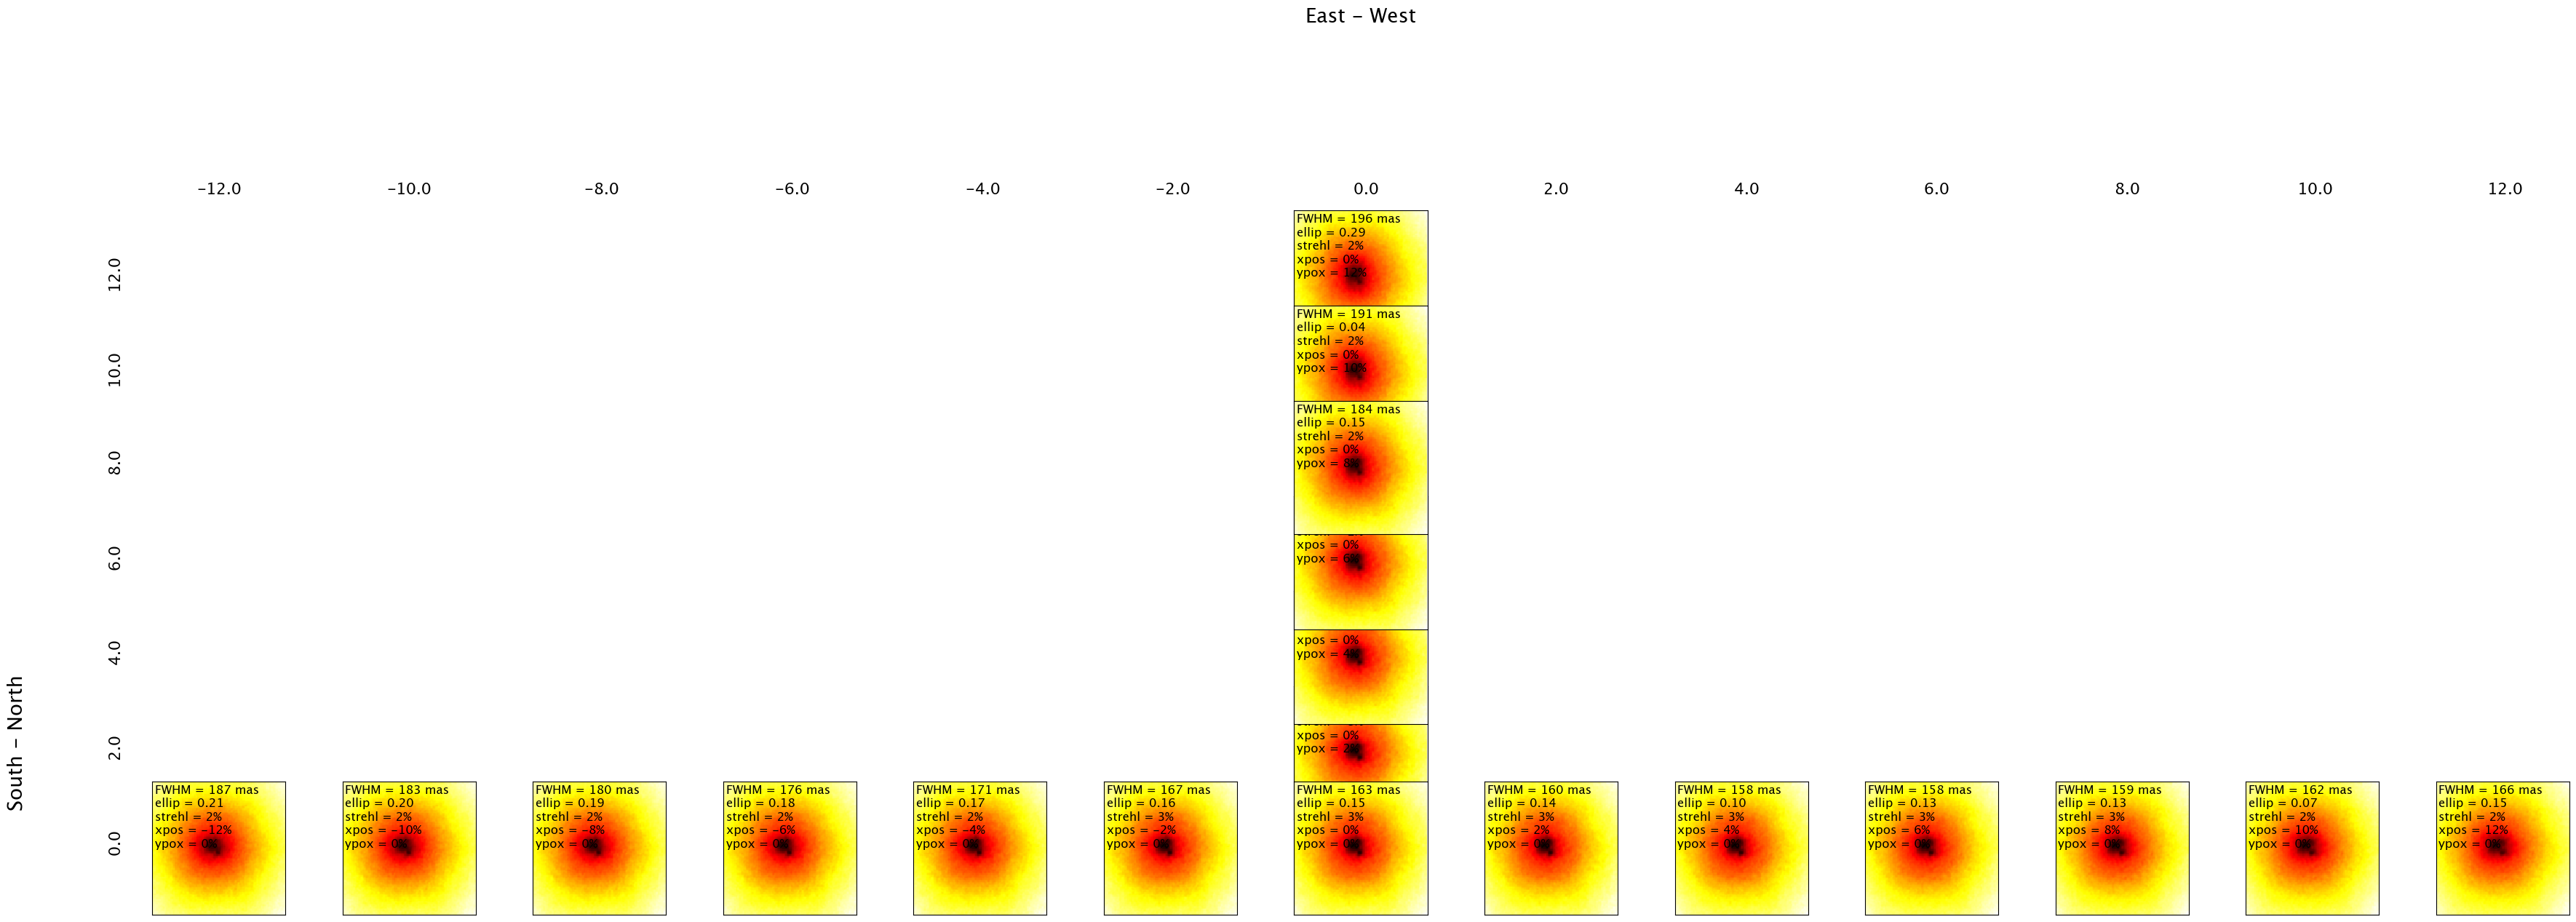

In [17]:
import copy
psf_stack_35 = copy.deepcopy(psf_stack)

idx = np.where(psf_stack_35.pos[:, 0] <= 35)[0]
psf_stack_35.psfs = psf_stack_35.psfs[idx]
psf_stack_35.pos = psf_stack_35.pos[idx]


psf_plots.plot_psf_stack(psf_stack_35, zoom=None, box_scale=1.4, figsize_max=40)

In [18]:
LGSpos = np.vstack([lgs_wfs_x, lgs_wfs_y]).T

In [19]:
psf_stack_all_wvl = psfs.MAOS_PSF_all_bands_stack(directory=directory, seed=seed, 
                                                  LGSpos=LGSpos, NGSpos=NGSpos, isgrid=False)
psf_stack_all_wvl.calc_metrics(parallel=True)

calc_stats in parallel with 6 cores.


In [20]:
psf_plots.plot_psf_stack_xpos_all_wave(psf_stack_all_wvl, 5., zoom=0.2, figsize_max=20, box_scale=1.8)

ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
psf_stack_all_wvl.metrics
